MISSING DATA ANALYSIS

In [2]:
# Cell 1 — imports and path
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
import os


PATH = "final_data.csv"   # dataset


In [ ]:
# Cell 2 — robust load function (handles common CSV/export quirks)
# robust_load(path): a function that attempts several ways to open your file safely
def robust_load(path):
    # try multiple encodings and sniff delimiter
    encodings = ['utf-8', 'latin1', 'cp1252', 'utf-16']
    for enc in encodings:
        try:
            with open(path, 'r', encoding=enc, errors='replace') as f:
                sample = f.read(8192)
                try:
                    dialect = csv.Sniffer().sniff(sample, delimiters=[',',';','\t','|'])
                    sep = dialect.delimiter
                except Exception:
                    sep = None
            if sep:
                df = pd.read_csv(path, encoding=enc, sep=sep, engine='python')
            else:
                df = pd.read_csv(path, encoding=enc, sep=None, engine='python')
            print(f"Loaded with encoding={enc}, sep={sep or 'inferred'}")
            return df
        except Exception as e:
            # try next encoding
            continue
    # fallback: try Excel
    try:
        df = pd.read_excel(path)
        print("Loaded as Excel via pandas.read_excel()")
        return df
    except Exception:
        raise RuntimeError("Failed to load file. Try re-saving as CSV UTF-8 or Excel (.xlsx).")

# load
df = robust_load(PATH)
print("Shape:", df.shape)


Loaded with encoding=utf-8, sep=,
Shape: (20430, 8)


In [ ]:
# Cell 3 — quick cleanup: strip column names, preview
# Removes leading/trailing whitespace from column names (common source of bugs like " Date" vs "Date")
df.columns = [c.strip() if isinstance(c, str) else c for c in df.columns]
print("Columns detected:", list(df.columns))

# preview head
display(df.head(8))


Columns detected: ['Scheme Code', 'Scheme Name', 'ISIN Div Payout/ISIN Growth', 'ISIN Div Reinvestment', 'Net Asset Value', 'Repurchase Price', 'Sale Price', 'Date']


,Scheme Code,Scheme Name,ISIN Div Payout/ISIN Growth,ISIN Div Reinvestment,Net Asset Value,Repurchase Price,Sale Price,Date
0,131741,Aditya Birla Sun Life Tax Savings Fund - Direc...,INF084M01BX0,NaN,57.19,57.19,57.19,02-Mar-2017
1,131741,Aditya Birla Sun Life Tax Savings Fund - Direc...,INF084M01BX0,NaN,57.33,57.33,57.33,03-Mar-2017
2,131741,Aditya Birla Sun Life Tax Savings Fund - Direc...,INF084M01BX0,NaN,57.57,57.57,57.57,06-Mar-2017
3,131741,Aditya Birla Sun Life Tax Savings Fund - Direc...,INF084M01BX0,NaN,57.52,57.52,57.52,07-Mar-2017
4,131741,Aditya Birla Sun Life Tax Savings Fund - Direc...,INF084M01BX0,NaN,57.50,57.50,57.50,08-Mar-2017
5,131741,Aditya Birla Sun Life Tax Savings Fund - Direc...,INF084M01BX0,NaN,57.52,57.52,57.52,09-Mar-2017
6,131741,Aditya Birla Sun Life Tax Savings Fund - Direc...,INF084M01BX0,NaN,57.52,57.52,57.52,10-Mar-2017
7,131741,Aditya Birla Sun Life Tax Savings Fund - Direc...,INF084M01BX0,NaN,58.23,58.23,58.23,14-Mar-2017


In [ ]:
# Cell 4 — parse Date if present and normalize numeric columns
# Detect common date column name
# parse Date and normalize numeric columns
date_col = None
for candidate in ['Date','date','DATE']:
    if candidate in df.columns:
        date_col = candidate
        break

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df = df.sort_values(date_col).reset_index(drop=True)
    print(f"Parsed date column: {date_col}  Range: {df[date_col].min()} to {df[date_col].max()}")
else:
    print("No Date column automatically detected.")

# Normalize numeric-like columns: remove commas and convert
def clean_numeric(col):
    if col not in df.columns: 
        return
    # only attempt if dtype object or contains commas/digits
    if df[col].dtype == object or df[col].astype(str).str.contains(',', na=False).any():
        cleaned = df[col].astype(str).str.replace(',', '', regex=False).replace({'nan': None, 'None': None, '': None})
        df[col] = pd.to_numeric(cleaned, errors='coerce')

# common numeric columns from your schema
for col in ['Net Asset Value','Repurchase Price','Sale Price','NAV']:
    if col in df.columns:
        clean_numeric(col)

# show types
display(df.dtypes)


Parsed date column: Date  Range: 2014-01-01 00:00:00 to 2020-04-03 00:00:00


Scheme Code                             int64
Scheme Name                            object
ISIN Div Payout/ISIN Growth            object
ISIN Div Reinvestment                  object
Net Asset Value                       float64
Repurchase Price                      float64
Sale Price                            float64
Date                           datetime64[ns]
initially_missing                        bool
dtype: object

In [ ]:
# Cell 5 — missingness summary (global)
# Calculates how many missing values each column has (missing_count) and what percent of the column is missing (missing_percent)
total_rows = len(df)
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).round(3).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_pct
}).reset_index().rename(columns={'index': 'column'})

display(missing_summary)

print(f"\nTotal rows: {total_rows}")
if 'Scheme Code' in df.columns:
    print("Unique Scheme Code count:", df['Scheme Code'].nunique())
if date_col:
    print("Date range:", df[date_col].min(), "to", df[date_col].max())


,column,missing_count,missing_percent
0,ISIN Div Reinvestment,11664,57.093
1,Repurchase Price,1716,8.399
2,Sale Price,1716,8.399
3,Scheme Code,0,0.000
4,ISIN Div Payout/ISIN Growth,0,0.000
5,Scheme Name,0,0.000
6,Net Asset Value,0,0.000
7,Date,0,0.000



Total rows: 20430
Unique Scheme Code count: 28
Date range: 2014-01-01 00:00:00 to 2020-04-03 00:00:00


In [ ]:
# Cell 6 — show top columns with missingness for quick copy into report
# Shows the top 20 offending columns (useful for larger tables)
# Quickly identify the main columns to focus on for imputation or exclusion.
top_missing = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
display(top_missing.head(20))


,column,missing_count,missing_percent
0,ISIN Div Reinvestment,11664,57.093
1,Repurchase Price,1716,8.399
2,Sale Price,1716,8.399


In [ ]:
# Cell 7 — missingness per scheme (important: NAV missingness per scheme)
# For each Scheme Code, computes the percentage of rows where Net Asset Value is missing.
# Shows schemes with the highest percentage of missing NAV.
if 'Scheme Code' in df.columns:
    miss_by_scheme = df.groupby('Scheme Code').apply(lambda g: g['Net Asset Value'].isnull().mean()).sort_values(ascending=False)
    miss_by_scheme = (miss_by_scheme * 100).round(3)
    miss_by_scheme = miss_by_scheme.to_frame('pct_nav_missing').reset_index()
    display(miss_by_scheme.head(40))  # top 40 schemes with highest % missing NAV
else:
    print("Scheme Code column not found; skipping per-scheme missingness.")


C:\Users\Sanya Vaishnavi\AppData\Local\Temp\ipykernel_6512\1777131920.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  miss_by_scheme = df.groupby('Scheme Code').apply(lambda g: g['Net Asset Value'].isnull().mean()).sort_values(ascending=False)


,Scheme Code,pct_nav_missing
0,100337,0.0
1,100338,0.0
2,102315,0.0
3,102316,0.0
4,102317,0.0
5,103558,0.0
6,103559,0.0
7,111677,0.0
8,111678,0.0
9,112537,0.0


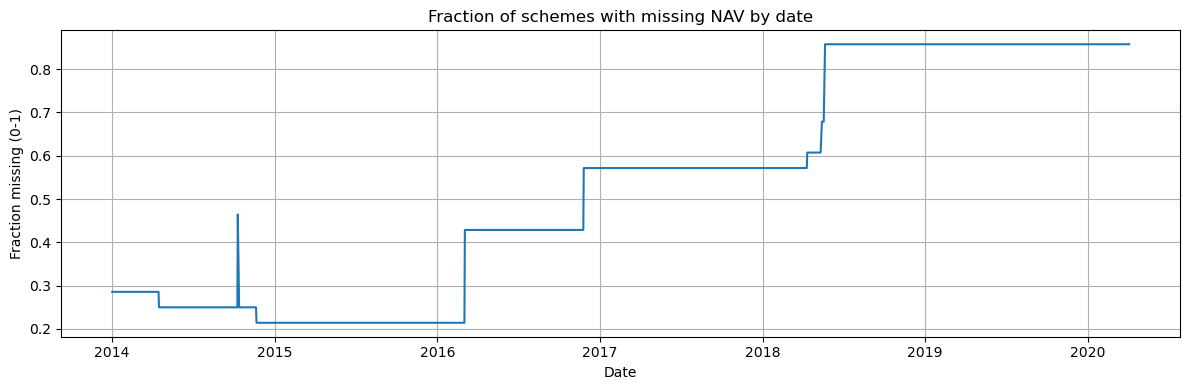

In [ ]:
# Cell 8 — missingness over time: fraction of schemes missing NAV on each date
# For each date, computes the fraction of schemes that have missing NAV on that date.
# Plots this fraction over time.
if date_col and 'Net Asset Value' in df.columns:
    nav_wide = df.pivot(index=date_col, columns='Scheme Code', values='Net Asset Value')
    missing_fraction_by_date = nav_wide.isnull().mean(axis=1)  # fraction of schemes missing on each date
    # plot
    plt.figure(figsize=(12,4))
    plt.plot(missing_fraction_by_date.index, missing_fraction_by_date.values)
    plt.title('Fraction of schemes with missing NAV by date')
    plt.xlabel('Date')
    plt.ylabel('Fraction missing (0-1)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to build timeline missingness (need Date + Net Asset Value).")


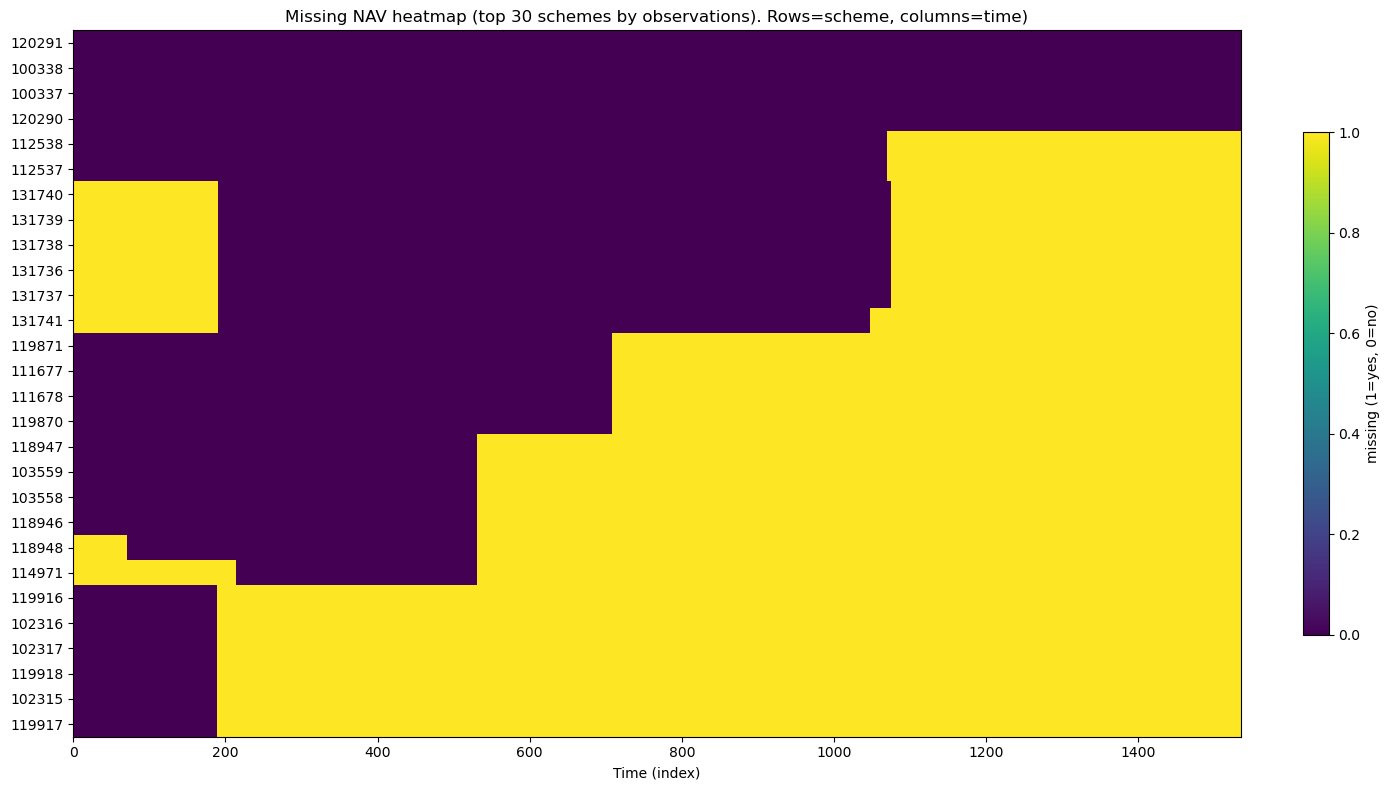

In [ ]:
# Cell 9 — heatmap of missingness across top N schemes (visual)
# Create boolean matrix: True if missing (Creates a 2D image where each row is a scheme and each column a date; cells are 1 if missing, 0 if present.)
if date_col and 'Net Asset Value' in df.columns:
    # pick top N schemes by observation count
    counts = df['Scheme Code'].value_counts()
    top_n = 30
    top_schemes = counts.head(top_n).index.tolist()
    mat = nav_wide[top_schemes].isnull().T  # schemes x dates (True = missing)
    plt.figure(figsize=(14,8))
    # imshow expects numeric; convert boolean->int
    plt.imshow(mat.astype(int), aspect='auto', interpolation='nearest')
    plt.yticks(range(len(top_schemes)), top_schemes)
    plt.xlabel('Time (index)')
    plt.title(f'Missing NAV heatmap (top {top_n} schemes by observations). Rows=scheme, columns=time)')
    plt.colorbar(label='missing (1=yes, 0=no)', orientation='vertical', fraction=0.02)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to build heatmap (need Date + Net Asset Value).")


In [ ]:
# Cell 10 — analysis of gap lengths per scheme (consecutive missing runs)
# n_gaps = number of missing-run segments,
# avg_gap_len = average length of those gaps (in rows/dates),
# max_gap_len = longest consecutive missing run.

def consecutive_nan_runs(s):
    # s is a Series (NAV) indexed by date (sorted)
    isna = s.isna().astype(int)
    # compute run lengths
    runs = []
    run_len = 0
    for v in isna:
        if v == 1:
            run_len += 1
        else:
            if run_len > 0:
                runs.append(run_len)
            run_len = 0
    if run_len > 0:
        runs.append(run_len)
    return runs

if date_col and 'Net Asset Value' in df.columns:
    gap_stats = []
    for code, g in df.groupby('Scheme Code'):
        s = g.set_index(date_col).sort_index()['Net Asset Value']
        runs = consecutive_nan_runs(s)
        if len(runs) == 0:
            gap_stats.append((code, 0, 0, 0))  # no gaps
        else:
            gap_stats.append((code, len(runs), np.mean(runs), max(runs)))
    gap_df = pd.DataFrame(gap_stats, columns=['Scheme Code','n_gaps','avg_gap_len','max_gap_len'])
    gap_df = gap_df.sort_values('max_gap_len', ascending=False)
    display(gap_df.head(40))
else:
    print("Insufficient data to compute gap runs.")


,Scheme Code,n_gaps,avg_gap_len,max_gap_len
0,100337,0,0,0
1,100338,0,0,0
2,102315,0,0,0
3,102316,0,0,0
4,102317,0,0,0
5,103558,0,0,0
6,103559,0,0,0
7,111677,0,0,0
8,111678,0,0,0
9,112537,0,0,0


In [ ]:
# Cell 11 — create an 'imputed_flag' placeholder (empty mask). 
# Creates a boolean mask that marks which NAV cells were missing in the original wide pivot.
# We'll fill this later when we impute; for now it records which cells are missing.
if date_col and 'Net Asset Value' in df.columns:
    # pivot back to long form with imputed flag column (False = not imputed; True = imputed)
    nav_mask = nav_wide.isnull()  # True when missing initially
    # turn into a long DataFrame of mask values
    mask_long = nav_mask.stack().reset_index()
    mask_long.columns = [date_col, 'Scheme Code', 'initially_missing']
    # join back to original df on (Date, Scheme Code) so you get a column you can reference
    df = df.merge(mask_long, how='left', on=[date_col, 'Scheme Code'])
    # where not found, set False
    df['initially_missing'] = df['initially_missing'].fillna(False)
    print("Added column 'initially_missing' (True where NAV was missing in original pivot).")
    display(df[['Scheme Code','Date','Net Asset Value','initially_missing']].head(10))
else:
    print("Skipping imputed_flag creation (insufficient columns).")


Added column 'initially_missing' (True where NAV was missing in original pivot).


,Scheme Code,Date,Net Asset Value,initially_missing
0,119918,2014-01-01,31.7000,False
1,102317,2014-01-01,31.2800,False
2,119917,2014-01-01,15.6100,False
3,103558,2014-01-01,14.6295,False
4,120291,2014-01-01,43.7693,False
5,102315,2014-01-01,31.2400,False
6,102316,2014-01-01,15.4100,False
7,111677,2014-01-01,20.2890,False
8,119871,2014-01-01,20.4750,False
9,118946,2014-01-01,14.8984,False


In [ ]:
# Cell 12 — export summaries to CSVs for reporting or manual inspection
# Saves the summary tables and gap stats to CSV files in a folder missing_analysis_outputs/ for later reference or inclusion in reports.
os.makedirs('missing_analysis_outputs', exist_ok=True)
missing_summary.to_csv('missing_analysis_outputs/missing_by_column.csv', index=False)
if 'miss_by_scheme' in locals():
    miss_by_scheme.to_csv('missing_analysis_outputs/missing_by_scheme_pct_nav.csv', index=False)
if 'gap_df' in locals():
    gap_df.to_csv('missing_analysis_outputs/gap_stats_by_scheme.csv', index=False)
if 'nav_wide' in locals():
    nav_wide.isnull().mean(axis=1).to_csv('missing_analysis_outputs/fraction_missing_by_date.csv')
print("Saved CSV summaries to missing_analysis_outputs/ folder.")


Saved CSV summaries to missing_analysis_outputs/ folder.
